In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.datasets import fetch_datasets
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import (
    cross_validate, 
    train_test_split, 
    TunedThresholdClassifierCV,
)

In [2]:
import warnings
warnings.filterwarnings("ignore", message="lbfgs failed to converge after")

## Load protein homology dataset

In [3]:
# Load dataset from imbalanced-learn.
def load_dataset(dataset):
    
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    X, y = data.data, data.target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0)
    
    return X_train, X_test, y_train, y_test

In [4]:
X_train, X_test, y_train, y_test = load_dataset("protein_homo")

print(f"Target mean: {np.mean(y_train):.4f}")

Target mean: 0.0087


## Select best model

We want to classify mails correctly. We optimise for the balanced accuracy and the optimal threshold.

In [5]:
# Machine learning models to train:
models = {
    "Logistic Regression": LogisticRegression(max_iter=100, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=10, random_state=42),
    "GBM":                 GradientBoostingClassifier(n_estimators=5, random_state=42),
}

# Wrap each in TunedThresholdClassifierCV optimising 
# for balanced accuracy:
tuned_models = {
    name: TunedThresholdClassifierCV(
        estimator=model,
        scoring="balanced_accuracy",
        store_cv_results=True,
        cv=5,
        refit=True,
    )
    for name, model in models.items()
}

## Performance dispersion

### With threshold tuning

In [6]:
cv_results = {}

for name, model in models.items():
    tuned = TunedThresholdClassifierCV(
        estimator=model,
        scoring="balanced_accuracy",
    )
    cv = pd.DataFrame(
        cross_validate(
            tuned,
            X_train,
            y_train,
            scoring="balanced_accuracy",
            cv=5,
            return_train_score=True,
        )
    )
    cv_results[name] = {
        "train_mean": cv["train_score"].mean(),
        "train_std":  cv["train_score"].std(),
        "test_mean":  cv["test_score"].mean(),
        "test_std":   cv["test_score"].std(),
    }

summary = pd.DataFrame(cv_results).T
print(summary)

                     train_mean  train_std  test_mean  test_std
Logistic Regression    0.923207   0.001692   0.922915  0.015530
Random Forest          0.994572   0.000124   0.918087  0.011156
GBM                    0.900175   0.005107   0.874614  0.016558


### Without threshold tuning

In [7]:
# CV without threshold tuning
cv_results_base = {}

for name, model in models.items():
    cv = pd.DataFrame(
        cross_validate(
            model,
            X_train,
            y_train,
            scoring="balanced_accuracy",
            cv=5,
            return_train_score=True,
        )
    )
    cv_results_base[name] = {
        "test_mean": cv["test_score"].mean(),
        "test_std":  cv["test_score"].std(),
    }

summary_base = pd.DataFrame(cv_results_base).T
print(summary)

                     train_mean  train_std  test_mean  test_std
Logistic Regression    0.923207   0.001692   0.922915  0.015530
Random Forest          0.994572   0.000124   0.918087  0.011156
GBM                    0.900175   0.005107   0.874614  0.016558


### Plot

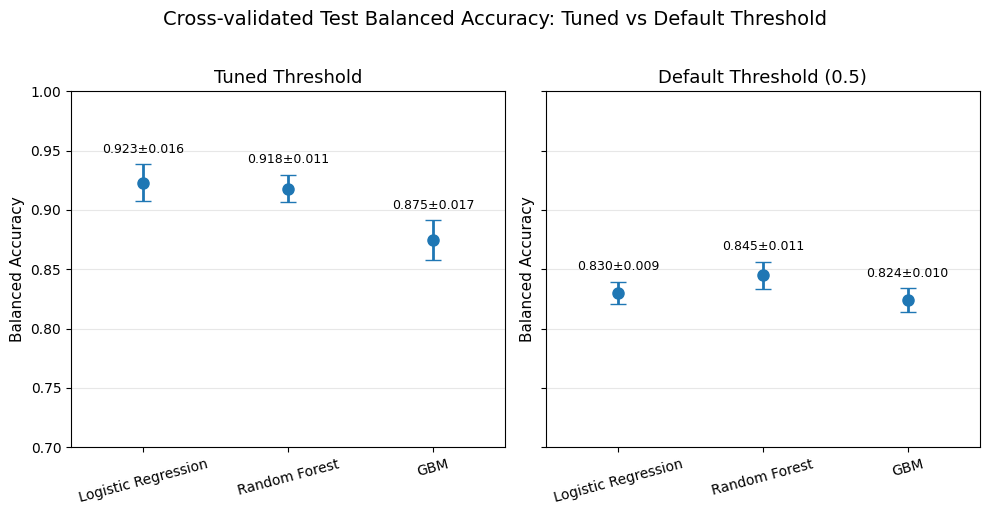

In [11]:
# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, (summ, title) in zip(axes, [
    (summary,      "Tuned Threshold"),
    (summary_base, "Default Threshold (0.5)"),
]):
    means = summ["test_mean"]
    stds  = summ["test_std"]
    ax.errorbar(x=summ.index, y=means, yerr=stds,
                fmt='o', capsize=6, markersize=8, linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("Balanced Accuracy", fontsize=11)
    ax.set_ylim(0.7, 1)
    ax.set_xlim(-0.5, 3 - 0.5)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')
    for x, (mean, std) in enumerate(zip(means, stds)):
        ax.text(x, mean + std + 0.01,
                f"{mean:.3f}±{std:.3f}", ha='center', fontsize=9)

plt.suptitle("Cross-validated Test Balanced Accuracy: Tuned vs Default Threshold",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch2/ch2-fig5.png', dpi=300, bbox_inches='tight')
plt.show()